# Attendance

[The link to SEAts](https://gold.seats.cloud/angular/#/lectures)

# 15 Language models and the Transformer

In [1]:
import os
import re
import sys
import random
import shutil
import string
import pathlib

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from IPython.core.magic import register_cell_magic

os.environ["KERAS_BACKEND"] = "jax"

import keras
import keras_hub

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## The Language Model

Skipping the [Shakespeare GRU model](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer/#training-a-shakespeare-language-model), since we're going to do this in the Text Generation notebook!

## Sequence-to-Sequence Learning

### The Seq-to-Seq Model

<!-- <img style="height:700px" src="images/nlp/stanford.seq2seq.png"> -->
<img style="height:700px" src="https://github.com/jchwenger/DLWP/blob/main/lectures/08/images/nlp/stanford.seq2seq.png?raw=true">

<small>[Chris Manning, CS224N, Stanford](https://web.stanford.edu/class/cs224n/index.html), [lecture 7](https://web.stanford.edu/class/cs224n/slides/cs224n-2022-lecture07-nmt.pdf)  
The original paper: ["Sequence to Sequence Learning with Neural Networks"](https://arxiv.org/abs/1409.3215)</small>

### English-to-Spanish Translation

In [2]:
MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

DATASET_DIR = pathlib.Path("spa-eng")

if not DATASET_DIR.exists():
    !wget http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
    !unzip -q spa-eng.zip

--2026-03-06 12:56:24--  http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.170.207, 142.251.10.207, 142.251.12.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.170.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2638744 (2.5M) [application/zip]
Saving to: ‘spa-eng.zip’

spa-eng.zip         100%[===================>]   2.52M  1.87MB/s    in 1.3s    

2026-03-06 12:56:25 (1.87 MB/s) - ‘spa-eng.zip’ saved [2638744/2638744]



Other languages available [here](https://www.manythings.org/anki/)!

In [3]:
TEXT_FILE = DATASET_DIR / "spa.txt"

with TEXT_FILE.open() as f:
    lines = f.read().strip().split("\n")

text_pairs = []
# spa.txt is tab separated, but the other datasets use spaces
separator = "\t" if "\t" in lines[0] else " "

for line in lines:
    # for datasets other than the official one, only tak
    english, spanish = line.split(separator)[:2]
    spanish = "[start] " + spanish + " [end]"
    text_pairs.append((english, spanish))

In [4]:
print(random.choice(text_pairs))

('He has very bad luck.', '[start] Tiene una suerte negra. [end]')


In [5]:
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples:num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples:]

#### Vectorizing the English and Spanish text pairs

In [6]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", "")

VOCAB_SIZE = 15000
SEQUENCE_LENGTH = 20

english_tokenizer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)
spanish_tokenizer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH + 1,
    standardize=custom_standardization,
)
train_english_texts = [pair[0] for pair in train_pairs]
train_spanish_texts = [pair[1] for pair in train_pairs]
english_tokenizer.adapt(train_english_texts)
spanish_tokenizer.adapt(train_spanish_texts)

#### Preparing datasets for the translation task

In [7]:
BATCH_SIZE = 64

def format_dataset(eng, spa):
    eng = english_tokenizer(eng)
    spa = spanish_tokenizer(spa)
    features = {"english": eng, "spanish": spa[:, :-1]}
    labels = spa[:, 1:]
    sample_weights = labels != 0
    return features, labels, sample_weights


def make_dataset(pairs):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).prefetch(16).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

##### Test dataset

In [8]:
for inputs, targets, _ in train_ds:
    print(f"inputs['english'].shape: {inputs['english'].shape}, dtype: {inputs['english'].dtype}")
    print(f"inputs['spanish'].shape: {inputs['spanish'].shape}, dtype: {inputs['spanish'].dtype}")
    print(f"targets.shape: {targets.shape}, dtype: {targets.dtype}")
    break

inputs['english'].shape: (64, 20), dtype: <dtype: 'int64'>
inputs['spanish'].shape: (64, 20), dtype: <dtype: 'int64'>
targets.shape: (64, 20), dtype: <dtype: 'int64'>


In [9]:
vocabulary_en = [str(s) for s in english_tokenizer.get_vocabulary()]
vocabulary_spa = [str(s) for s in spanish_tokenizer.get_vocabulary()]
# vocabulary
def detokenize(toks, vocab_list):
    return " ".join([vocab_list[t] for t in toks])

In [10]:
for inputs, _, _ in train_ds:
    # take the first sequence
    eng = inputs["english"][0]
    spa = inputs["spanish"][0]

    print(eng.shape, spa.shape)
    print(detokenize(eng, vocabulary_en))
    print(detokenize(spa, vocabulary_spa))
    break

(20,) (20,)
he is no longer here               
[start] Él ya no está aquí [end]             


---

### Sequence-to-sequence learning with RNNs

#### GRU-based encoder

In [11]:
EMBED_DIM = 256
LATENT_DIM = 1024

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(source)
encoded_output = keras.layers.Bidirectional(
    keras.layers.GRU(LATENT_DIM), merge_mode="sum"
)(x)

#### GRU-based decoder and the end-to-end model

In [12]:
past_target = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(past_target)
rnn_layer = keras.layers.GRU(LATENT_DIM, return_sequences=True)
x = rnn_layer(x, initial_state=encoded_output)
x = keras.layers.Dropout(0.5)(x)
target_predictions = keras.layers.Dense(VOCAB_SIZE, activation="softmax")(x)
seq2seq_rnn = keras.Model([source, past_target], target_predictions)

In [13]:
seq2seq_rnn.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ english (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ spanish (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, None, 256) │   3,840,000 │ english[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ not_equal (NotEqual)  │ (None, None)      │           0 │ english[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding_1           │ (None, None, 256) │   3,840,000 │ spanish[0][0]      │
│ (Embedding)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bidirectional         │ (None, 1024)      │   7,876,608 │ embedding[0][0],   │
│ (Bidirectional)       │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gru_1 (GRU)           │ (None, None,      │   3,938,304 │ embedding_1[0][0], │
│                       │ 1024)             │             │ bidirectional[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout (Dropout)     │ (None, None,      │           0 │ gru_1[0][0]        │
│                       │ 1024)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, None,      │  15,375,000 │ dropout[0][0]      │
│                       │ 15000)            │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 34,869,912 (133.02 MB)

 Trainable params: 34,869,912 (133.02 MB)

 Non-trainable params: 0 (0.00 B)

#### Training our recurrent sequence-to-sequence model

In [14]:
seq2seq_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"]
)

history = seq2seq_rnn.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "seq-to-seq-gru.en_spa.keras",
            save_best_only=True

        )
    ],
)

Epoch 1/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.2639 - loss: 4.5433 - val_accuracy: 0.4841 - val_loss: 2.5603
Epoch 2/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 55s 42ms/step - accuracy: 0.4958 - loss: 2.5200 - val_accuracy: 0.5848 - val_loss: 1.9387
Epoch 3/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 55s 42ms/step - accuracy: 0.5973 - loss: 1.7809 - val_accuracy: 0.6221 - val_loss: 1.7320
Epoch 4/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 54s 42ms/step - accuracy: 0.6616 - loss: 1.3421 - val_accuracy: 0.6407 - val_loss: 1.6424
Epoch 5/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 55s 42ms/step - accuracy: 0.7121 - loss: 1.0522 - val_accuracy: 0.6490 - val_loss: 1.6380
Epoch 6/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 41ms/step - accuracy: 0.7525 - loss: 0.8593 - val_accuracy: 0.6533 - val_loss: 1.6588
Epoch 7/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 41ms/step - accuracy: 0.7792 - loss: 0.7396 - val_accuracy: 0.6545 - val_loss: 1.6929
Epoch 8/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 41ms/step - accuracy: 0.7984 -

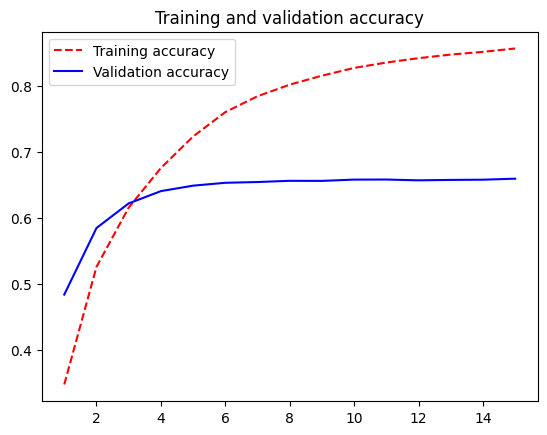

In [15]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [16]:
print(f"Val acc: {seq2seq_rnn.evaluate(val_ds)[1]:.3f}")

279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6584 - loss: 1.9634
Val acc: 0.660


#### Translating new sentences with our RNN encoder and decoder

In [17]:
def decode_sequence(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])
        next_token_predictions = seq2seq_rnn.predict(
            [tokenized_input_sentence, tokenized_target_sentence], verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

In [18]:
spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20
test_eng_texts = [pair[0] for pair in test_pairs]

In [19]:
for _ in range(20):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(decode_sequence(input_sentence))

-
He could hardly make himself understood.
[start] Él apenas podía entender [end]
-
Tom can sleep in my room.
[start] tom puede dormir en mi habitación [end]
-
She was injured in a car accident.
[start] ella resultó herido en un accidente automovilístico [end]
-
Even a child can do such a thing.
[start] incluso un niño puede hacer algo así [end]
-
They all have come.
[start] vinieron todos ellos [end]
-
They're right outside.
[start] están fuera de discusión [end]
-
The archer killed the deer.
[start] el [UNK] tuvo el ciervo [end]
-
Even though computer programmers may use semicolons every day, nowadays most people only use semicolons for emoticons.
[start] aunque a veces los pájaros pueden llegar a un par de personas casi todo el día de poder [UNK] [end]
-
You cannot do this.
[start] no puedes hacer esto [end]
-
How do you think I feel?
[start] cómo crees que me siento [end]
-
Tom couldn't find a good place to hide the key.
[start] tom no pudo encontrar un buen lugar para la llave [en

---

## The Transformer architecture

### Intro

<!-- <img style="float:right" src="images/transformer/the-annotated-transformer_14_0.transformer-full.png"> -->
<img style="float:right" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/the-annotated-transformer_14_0.transformer-full.png">


<small style="position:absolute;bottom:0;right:0">[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

The **Transformer** architecture was developed for NLP, specifically for translation.

The dual architecture pattern (*sequence to sequence*) reflects this:
- the left-hand side transforms an **input** sentence into abstract representations;
- the right hand side transforms the **output** sentence into abstract representations, integrating abstract representations from the **input sequence** as well;
- the output probabilities ("what is the next token?") are produced on the basis of both branches!

#### Transormers: before & after

<!-- <img style="float:right;height:650px" src="images/transformer/beyer.takeover.1.png"> -->
<img style="float:right;height:650px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.takeover.1.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit)</small>

<!-- <img style="float:right;height:650px" src="images/transformer/beyer.takeover.2.png"> -->
<img style="float:right;height:650px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.takeover.2.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit)</small>

---

### Note: Einstein Summation

See [this part](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer/#the-transformer-architecture) (scroll down a bit).

Rules:
- For any **repeated** letters across inputs, **multiply** values along these axes together (dimensions should match).
- For any letters in the input but **not** the output, **sum over these axes**.
- Output axes can be returned in **any order**.

In [20]:
a = np.random.randint(0, 5, size=(2,3))
# transpose: flip the dimensions
a_t = np.einsum("ij->ji", a)
print(f"{a.shape = } -> {a_t.shape = }")

a.shape = (2, 3) -> a_t.shape = (3, 2)


In [21]:
b = np.random.randint(0, 5, size=(3, 2))
# matmul: multiply along i & k, sum over j
a_mm_b = np.einsum("ij,jk->ik", a, b)
print(f"{a.shape = }, {b.shape = } -> {a_mm_b.shape = }")

a.shape = (2, 3), b.shape = (3, 2) -> a_mm_b.shape = (2, 2)


In [22]:
c = np.random.randint(0, 5, size=(3, 2,3))
# matmuls a batch of matrices against a single matrix
# multiply along h (broadcasting!), i, k, sum over j
c_mm_b = np.einsum("hij,jk->hik", c, b)
print(f"{c.shape = }, {b.shape = } -> {c_mm_b.shape = }")

c.shape = (3, 2, 3), b.shape = (3, 2) -> c_mm_b.shape = (3, 2, 2)


In [23]:
d = np.random.randint(0, 5, size=(3,))
# dot-product: multiply & sum over i
d_dot = np.einsum("i,i->", d, d)
print(f"{d.shape = } -> {d_dot.shape = }")

d.shape = (3,) -> d_dot.shape = ()


In [24]:
# element-wise multiplication
# multiply over i, j, k
c_elwise_mul_ = np.einsum("ijk,ijk->ijk", c, c)
print(f"{c.shape = } -> {c_elwise_mul_.shape = }")

c.shape = (3, 2, 3) -> c_elwise_mul_.shape = (3, 2, 3)


In [25]:
# element-wise multiplies and sums everything
# multiply & sum over i, j, k
c_elwise_mul_sum = np.einsum("ijk,ijk->", c, c)
print(f"{c.shape = } -> {c_elwise_mul_sum.shape = }")

c.shape = (3, 2, 3) -> c_elwise_mul_sum.shape = ()


Recommended tutorials and advanced techniques:
- [`np.einsum`](https://numpy.org/devdocs/reference/generated/numpy.einsum.html)
- [`torch.einsum`](https://docs.pytorch.org/docs/stable/generated/torch.einsum.html)
- [`keras.ops.einsum`](https://keras.io/api/ops/numpy/#einsum-function), [`keras.layers.EinsumDense`](https://keras.io/api/layers/core_layers/einsum_dense/)
- Separate [`einops`](https://github.com/arogozhnikov/einops) library with interesting example notebooks!

### Understanding self-attention

#### Generalized self-attention: the query-key-value model

<!-- ![Stanford CS224n soft look-up](images/cs224n/02.soft-lookup.png) -->
<img style="height:750px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/02.soft-lookup.png">

[Stanford CS224n, lecture 8](https://web.stanford.edu/class/cs224n/slides/cs224n-2023-lecture08-transformers.pdf#page=8&zoom=auto,-74,536) ([lecture](https://www.youtube.com/watch?v=LWMzyfvuehA))

<!-- <imgsrc="images/transformer/chollet.attention.2.png"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/chollet.attention.2.png">

DLWP, 2<sup>nd</sup> edition, p.338

### The operations of attention

1. First, we **transform our input sequence** $X$ `(timesteps_x, embedding_dim_x)` by integrating information from a context sequence $Y$ `(timesteps_y, embedding_dim_y)`, each token is a vector embedding) into **Keys**, **Queries**, and **Values**, using three different matrices (here denoted $W$):

$$
Q = XW_Q, \qquad K = YW_K, \qquad V = YW_V
$$

With:
- $t$ denotes time steps, $d$ embedding dimensions, $t_X$ and $t_Y$ are the lengths of the respective sequences, and $d_k$ is the space dimension of the attention operation, `attn_dim`:
- $X$: $t_X \times d_x$
- $Y$: $t_Y \times d_y$
- $W_Q$: $d_x \times d_k$, therefore $Q$: $ t_X \times d_k $
- $W_K$: $d_y \times d_k$, therefore  $K$: $ t_Y \times d_k$
- $W_V$: $d_y \times  d_{out}$, therefore $V$: $  t_Y \times d_{out}$

**Note**

Very often $X = Y$, we aggregate input $X$ with itself. That means that $d_X = d_Y$. Also, often $d_{out} = d_{embed}$: our output sequence has the same number of time steps as our input, and the same embedding dimension.

2. Then, we perform the **attention** proper:

$$
\begin{align*}
\mathrm{Attention}(Q, K, V) &= softmax(\frac{QK^T}{\sqrt{d_k}})V\\
\\
& = softmax(\frac{QK^T}{scaling})V \\
\\
&= \bbox[5px,border:2px solid red]{“softmax(\mathrm{Queries} \cdot \mathrm{Keys)} \cdot \mathrm{Values}”}\\
\\
&= \underbrace{ \underbrace{ softmax( \overbrace{ \mathrm{Queries} \cdot \mathrm{Keys} }^{  \text{how much each source token is compatible with all context tokens} } )  }_{ \text{turn compatibilities into a normalised mask} } \cdot \mathrm{Values}  }_{ \text{turn each token into a weighted average of all context tokens} }\\
\end{align*}
$$

$Q$: queries ($t_X \times d_k$)  
$K$: keys ($t_Y \times d_k$)  
$V$: values ($t_Y \times d_{out}$)  
$\sqrt{d_k}$: scaling factor, $d_k$: dimension of $Q$ (same as $K$), to prevent small gradients.

#### Attention: the maths

$$
\begin{aligned}
QK^T & =
\begin{pmatrix}
- & q_1 & -\\
- & \vdots & -\\
- & q_{t_X} & - \\
\end{pmatrix}_{t_X \times d_k} \begin{pmatrix}
| & | & |\\
k_1 & \cdots & k_{t_Y}\\
| & | & |\\
\end{pmatrix}_{d_k \times t_Y} =
\begin{pmatrix}
q_1 k_1 & \cdots & q_1 k_{t_Y}\\
\vdots & \cdots & \vdots \\
q_{t_X} k_1 & \cdots & q_{t_X} k_{t_Y}\\
\end{pmatrix}_{t_X \times t_Y} \\
\\
& =
\begin{pmatrix}
w_{11} & \cdots & w_{1 t_Y}\\
\vdots & \cdots & \vdots \\
w_{t_X1} & \cdots & w_{t_X t_Y}\\
\end{pmatrix}_{t_X \times t_Y} \\
\\
& \rightarrow \begin{pmatrix}
\frac{w_{11}}{\sqrt{d_k}} & \cdots & \frac{w_{1 t_Y}}{\sqrt{d_k}}\\
\vdots & \cdots & \vdots \\
\frac{w_{t_X 1}}{\sqrt{d_k}} & \cdots & \frac{w_{t_X t_Y}}{\sqrt{d_k}}\\
\end{pmatrix}_{t_X \times t_Y}
\end{aligned}
$$

Again, more often than not $t_X = t_Y$, therefore the attention matrix is square.

The number $w_{ij}$ describes who similar/close $q_i$ (the query for token i in the source) is to $k_j$ (the key for token j in the context).

Then we normalize along the rows, so that the numbers in each can be interpreted as weighting factors:

$$
\begin{pmatrix}
softmax( w_{11} & \cdots & w_{1 t_Y})\\
\vdots & \cdots & \vdots \\
softmax(w_{t_X 1} & \cdots & w_{t_X t_Y})\\
\end{pmatrix} =
\begin{pmatrix}
\frac{e^{ w_{11} } }{ \sum_i e^{w_{1i}} } & \cdots & \frac{e^{ w_{1 t_Y} } }{ \sum_i e^{w_{1i}} }\\
\vdots & \cdots & \vdots \\
\frac{e^{ w_{t_X 1} } }{ \sum_i e^{w_{t_X i} } } & \cdots & \frac{e^{ w_{d_k t_Y} } }{ \sum_i e^{w_{t_X i}} }\\
\end{pmatrix}  =
\begin{pmatrix}
w'_{11} & \cdots & w'_{1 t_Y}\\
\vdots & \cdots & \vdots \\
w'_{t_X 1} & \cdots & w'_{t_X t_Y}\\
\end{pmatrix}_{t_X \times t_Y} = A
$$


Mix the values using the normalized weights:

$$
\begin{aligned}
softmax(QK^T)V = A V & =
\begin{pmatrix}
- & w'_1 & -\\
- & \vdots & - \\
- & w'_{t_X} &  -\\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
- & v_1 & -\\
- & \cdots & -\\
- & v_{t_Y} & - \\
\end{pmatrix}_{t_Y \times d_{out}}\\
& =
\begin{pmatrix}
- & x'_1 & -\\
- & \vdots & - \\
- & x'_{t_X} &  -\\
\end{pmatrix}_{t_X \times d_{out}} = X'
\end{aligned}
$$

$X'$ is our output matrix (`timesteps_x`, `embedding_dim_x_prime`) composed of all $x'_i$ vectors representing each updated, 'enriched' tokens (having incorporated information from $Y$). More often than not, $d_{out} = d_X$, the embedding dimension of the output is the same as the one of the input.


Each new vector $v_i$ merges the all the dimensions of the previous vectors $v$ according to the weighting given by $w$:

$$
\begin{aligned}
& \begin{pmatrix}
- & w'_1 & -\\
- & \cdots & - \\
- & w'_{t_X} &  -\\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
- & v_1 & -\\
- & \vdots & -\\
- & v_{t_Y} & - \\
\end{pmatrix}_{t_Y \times d_{out}} = \\
\\
= & \begin{pmatrix}
- & \color{red}{w'_1} & -\\
\vdots & \cdots & \vdots \\
- & w'_{t_X} &  -\\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
\overbrace{\color{blue}{v_{11}}}^{ \color{blue}{v'_1}\text{: first dim across all } t_Y } & \cdots & v_{1 d_{out}} \\
\vdots & \cdots & \vdots \\
\color{blue}{v_{t_Y 1}} & \cdots & v_{t_Y  d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}} \\
\\
= & \begin{pmatrix}
\color{red}{w'_{11}} \color{blue}{v'_1} & \cdots & x'_1 & -\\
- & \cdots & \vdots & - \\
- & \cdots & x'_{t_X} &  -\\
\end{pmatrix}_{t_X \times d_{out}}
\end{aligned}
$$

$\color{red}{w_1}$, in this example, will control how much each of the $v$s will contribute to new, updated vector $x'_1$ (our updated vector representation for token 1).

Each $o_i$ will have aggregated information from all $v$ (including itself) using the normalised weighting $w_i$.


#### Note

- We saw the concept of a **gate** being like a smooth 1/0 switch. Here the *softmax* is used in the same way, for a whole array of values (letting more or less information flow through from different tokens as you mix/average their values).
- The dot product is a fairly straightforward **similarity measure** between two vectors.

### Causal Masking: Preventing look-aheads

Notice the **optional masking operation**: on the right-hand side of the Transformer (generation), we use a mask that effectively prevents any look-up into the future.

<!-- <img style="float:right;height:300px" src="images/transformer/the-annotated-transformer_33_0.attention.png"> -->
<img  style="float:right;height:300px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/the-annotated-transformer_33_0.attention.png">

<small style="position:absolute;bottom:0;right:0">[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

<!-- ![Stanford CS224n masked attention](images/cs224n/08.masked-attention.png) -->
<img style="height: 400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/08.masked-attention.png">

[Stanford CS224n, lecture 8, p.19](https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1234/slides/cs224n-2023-lecture08-transformers.pdf) ([lecture](https://www.youtube.com/watch?v=LWMzyfvuehA))

#### Masking: the maths

What happens when we use causal masking?

$$
\begin{aligned}
\begin{pmatrix}
w_{11} & - \infty & - \infty & \cdots & - \infty\\
w_{21} & w_{22} & - \infty & \cdots & - \infty\\
\vdots & \cdots & \cdots & \cdots& \vdots \\
w_{t_X 1} & \cdots & \cdots & w_{t_X t_Y}\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
v_{11} & \cdots & v_{1 d_{out}} \\
v_{21} & \cdots & v_{2 d_{out}} \\
\vdots & \cdots & \vdots \\
v_{t_Y 1} & \cdots & v_{t_Y d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}} & \rightarrow\\
\begin{pmatrix}
softmax( w_{11} & - \infty & - \infty & \cdots& - \infty)\\
softmax(w_{21} & w_{22} & - \infty  &\cdots & - \infty)\\
\vdots & \cdots & \cdots & \cdots & \vdots \\
softmax(w_{t_X 1} & \cdots & \cdots & \cdots& w_{t_X t_Y})\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
v_{11} & \cdots & v_{1 d_{out}} \\
v_{21} & \cdots & v_{2 d_{out}} \\
\vdots & \cdots & \vdots \\
v_{t_Y 1} & \cdots & v_{t_Y d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}} & \rightarrow \\
\begin{pmatrix}
\color{red}{w'_{11} (=1)} & 0 & 0 & \cdots & 0\\
\color{green}{w'_{21}} & \color{green}{w'_{22}} & 0 & \cdots & 0\\
\vdots & \cdots & \cdots & \cdots & \vdots \\
\color{orange}{w'_{t_X 1}} & \cdots & \cdots & \cdots &  \color{orange}{w'_{t_X t_Y}} \\
\end{pmatrix}_{t_X \times t_Y}
\begin{pmatrix}
\color{blue}{v_{11}} & \cdots & v_{1 d_{out}} \\
\color{blue}{v_{21}} & \cdots & v_{2 d_{out}} \\
\vdots & \cdots & \vdots \\
\color{blue}{v_{t_Y 1}} & \cdots & v_{t_Y d_{out}} \\
\end{pmatrix}_{t_Y \times d_{out}}  &=
\begin{pmatrix}
\color{red}{w'_{11} (=1)} \color{blue}{v_{11}} & \cdots & y_1 & - \\
\color{green}{w'_{21}} \color{blue}{v_{11}} + \color{green}{w'_{22}} \color{blue}{v_{21}} & \cdots & y_2 & -\\
\vdots & \cdots & \vdots & - \\
\sum_i \color{orange}{w_{t_X i}} \color{blue}{v_{i1}} & \cdots & y_{t_X} &  -\\
\end{pmatrix}_{t_X \times d_{out}}
\end{aligned}
$$

$y_1$ only aggregates itself, $y_2$ aggregates itself and $y_1$, and $y_{d_k}$ aggregates all rows (all time steps).


---

### Multi-head attention

The author found it beneficial to **subdivide the embedding space** into multiple $Queries$, $Keys$ and $Values$, each called **attention heads** looking for different *types* of information (each looks at the **whole sequence** differently)! Perk: the overall matrix multiplication operations and shapes remain the same.

*Similar to the idea of several kernels scanning the same image in search of different features!*

<!-- <img style="float:right;height:400px" src="images/transformer/the-annotated-transformer_38_0.multi-head.png"> -->
<img style="float:right;height:400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/the-annotated-transformer_38_0.multi-head.png">


<small style="position:absolute;bottom:0;right:0">[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

<!-- ![Stanford CS224n multi-head attention](images/cs224n/06.multi-head.2.png) -->
<img style="height:400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/06.multi-head.2.png">

[Stanford CS224n, lecture 8, p.26](https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1234/slides/cs224n-2023-lecture08-transformers.pdf) ([lecture](https://www.youtube.com/watch?v=LWMzyfvuehA))

#### Multi-head attention: the maths

Split $Q$ and $K$ along the embedding dimension (the last one):
$$
Q = \begin{pmatrix}
- & \cdots & q_1 & \cdots & -\\
- & \cdots &  \vdots & \cdots & -\\
- & \cdots &  q_{t_X} & \cdots & - \\
\end{pmatrix}_{t_X \times d_k} \rightarrow Q^{h_1} = \begin{pmatrix}
- q_1^{h_1} -\\
\vdots\\
- q_{t_X}^{h_1} - \\
\end{pmatrix}_{t_X \times d_h}, Q^{h_2} = \begin{pmatrix}
- q_1^{h_2} -\\
\vdots\\
- q_{t_X}^{h_2} - \\
\end{pmatrix}_{t_X \times d_h}, \cdots
$$

$d_h$ is the dimension of the embedding dimension after division ($d_h = \lfloor d_k / \text{num\_heads} \rfloor)$, with usually a check forcing $d_k$ to be divisible by `num_heads` without remainder.

$$
K^T = \begin{pmatrix}
| & | & |\\
\vdots & \vdots & \vdots \\
k_1 & \cdots & k_{t_Y}\\
\vdots & \vdots & \vdots \\
| & | & |\\
\end{pmatrix}_{d_k \times t_Y} \rightarrow \begin{array}{11}
K^{Th_1} & = \begin{pmatrix} \
| &  & |\\
k_1^{h_1} & \cdots & k_{t_Y}^{h_1}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y},\\
\\
K^{Th_2} & = \begin{pmatrix} \
| &  & |\\
k_1^{h_2} & \cdots & k_{t_Y}^{h_2}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y},\\
& \vdots \ \ \ \ \ \ \ \ \
\end{array}
$$

Compute each of the attention submatrices:

$$
\begin{aligned}
Q^{h_1} K^{Th_1} = \begin{pmatrix}
- q_1^{h_1} -\\
\vdots\\
- q_{t_X}^{h_1} - \\
\end{pmatrix}_{t_X \times d_h} \begin{pmatrix}
| &  & |\\
k_1^{h_1} & \cdots & k_{t_Y}^{h_1}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y} & = \begin{pmatrix}
w_{11}^{h_1} & \cdots & w_{1 t_Y}^{h_1}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_1} & \cdots & w_{t_X t_Y}^{h_1}\\
\end{pmatrix}_{t_X \times t_Y} = A^{h_1}, \\
\\
Q^{h_2} K^{Th_2} = \begin{pmatrix}
- q_1^{h_2} -\\
\vdots\\
- q_{t_X}^{h_2} - \\
\end{pmatrix}_{t_X \times d_h} \begin{pmatrix}
| &  & |\\
k_1^{h_2} & \cdots & k_{t_Y}^{h_2}\\
| &  & |\\
\end{pmatrix}_{d_h \times t_Y} & = \begin{pmatrix}
w_{11}^{h_2} & \cdots & w_{1 t_Y}^{h_2}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_2} & \cdots & w_{t_X t_Y}^{h_2}\\
\end{pmatrix}_{t_X \times t_Y}  = A^{h_2}, \\
\\
& \vdots
\end{aligned}
$$

Each of those is the same size as our original attention matrix (`input_seq_len` x `context_seq_len`), but the actual number of operations to produce those is the same.

Peform the scaling, softmax and masking as before, then perform the matrix multiplication with the values, themselves split in the same way along the embedding axis:

$$
\begin{aligned}
A^{h_1} V^{h_1} = \begin{pmatrix}
w_{11}^{h_1} & \cdots & w_{1 t_Y}^{h_1}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_1} & \cdots & w_{t_X t_Y}^{h_1}\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
- & v_1^{h_1} & -\\
- & \vdots & -\\
- & v_{t_Y}^{h_1} & - \\
\end{pmatrix}_{t_Y \times d_h} & = \begin{pmatrix}
- & x_1^{h_1} & -\\
- & \vdots & - \\
- & x_{t_X}^{h_1} &  -\\
\end{pmatrix}_{t_X \times d_h} = X'^{\ h_1}, \\
\\
A^{h_2} V^{h_2} = \begin{pmatrix}
w_{11}^{h_2} & \cdots & w_{1 t_Y}^{h_2}\\
\vdots & \cdots & \vdots \\
w_{t_X1}^{h_2} & \cdots & w_{t_X t_Y}^{h_2}\\
\end{pmatrix}_{t_X \times t_Y} \begin{pmatrix}
- & v_1^{h_2} & -\\
- & \vdots & -\\
- & v_{t_Y}^{h_2} & - \\
\end{pmatrix}_{t_Y \times d_h} & = \begin{pmatrix}
- & x_1^{h_2} & -\\
- & \vdots & - \\
- & x_{t_X}^{h_2} &  -\\
\end{pmatrix}_{t_X \times d_h} = X'^{\ h_2}, \\
\\
& \vdots
\end{aligned}
$$

Finally, concatenate the result to obtain a matrix of the same shape as the one we would have had without the multi-head split:

$$
\begin{bmatrix}
 X'^{\ h_1} & X'^{\ h_2} & \cdots
\end{bmatrix} =
\begin{pmatrix}
- & x_1^{h_1} & -, &  - & x_1^{h_2} & -, & \cdots \\
- & \vdots & -, & - & \vdots & -, & \cdots \\
- & x_{t_X}^{h_1} & -, & - & x_{t_X}^{h_2} &  -, & \cdots \\
\end{pmatrix}_{t_X \times d_{out}} = \begin{pmatrix}
- & \cdots & x'_1 & \cdots & -\\
- & \cdots & \vdots & \cdots & - \\
- & \cdots & x'_{t_X} & \cdots &  -\\
\end{pmatrix}_{t_X \times d_{out}}
$$

### Visualising what Attention learns

Attention allows a network to make decisions about the importance of various parts of the input, and learn **complex internal patterns**.

In this example, "it" could refer to "animal" or to "street", and resolving this depends on **meaning** (and syntax). After attention, the embedding for "it" will have changed according to its context!

<!-- <div style="display:flex;justify-content:center">
    <img src="images/transformer/attention.png">
    <img src="images/transformer/attention.2.png">
</div> -->

<div style="display:flex">
    <img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/attention.png">
    <img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/attention.2.png">
</div>

<small>["Transformer: A Novel Neural Network Architecture for Language Understanding", Google Reseearch Blog](https://ai.googleblog.com/2017/08/transformer-novel-neural-network.html)</small>

See also the BERT visualisation in the reference notebook.

#### Code: Visualising Attention

source.shape = (1, 10, 3)
target.shape = (1, 7, 3)
attn.shape = TensorShape([1, 7, 7])
updated_target.shape = (1, 7, 3)


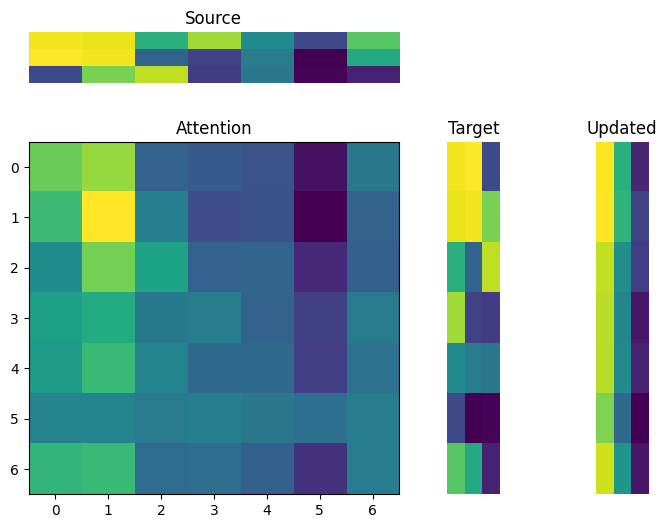

In [26]:
# see: https://chatgpt.com/share/69a0845f-6640-8005-9af5-010b9c9515c6
#      https://chatgpt.com/share/69a9b409-1de0-8005-a39c-1f83ea2e26d6

def dot_product_attention(target, source):
    # Takes the dot-product between all target and source vectors, where
    # b = batch size, t = target length, s = source length, d = vector size
    scores = np.einsum("btd,bsd->bts", target, source)
    scores = keras.ops.softmax(scores, axis=-1)
    # print("scores shape:", scores.shape)
    # Computes a weighted sum of all source vectors for each target vector
    return scores, np.einsum("bts,bsd->btd", scores, source)

# np.random.seed(12)
embedding_dim = 3
source = np.random.uniform(size=(1,10, embedding_dim))
target = np.random.uniform(size=(1,7, embedding_dim))
print(f"{source.shape = }")
print(f"{target.shape = }")

# self-attention, comment this to use the two separate vectors
source = target

attn, updated_target = dot_product_attention(target, source)
print(f"{attn.shape = }")
print(f"{updated_target.shape = }")

S = source.shape[1]
T = target.shape[1]

channel = 0

fig = plt.figure(figsize=(8,6))

# 3 rows, 5 columns (two spacers)
gs = gridspec.GridSpec(
    3, 5,
    width_ratios=[S, 0.1, 1, 1, 1],
    height_ratios=[1, 0.1, T],
)

# Source
ax_source = fig.add_subplot(gs[0,0])
ax_source.imshow(source[0].T, aspect="auto")
ax_source.axis("off")
ax_source.set_title("Source")

# Attention
ax_attn = fig.add_subplot(gs[2,0])
ax_attn.imshow(attn[0], aspect="auto")
ax_attn.set_title("Attention")

# Target
ax_target = fig.add_subplot(gs[2,2], sharey=ax_attn)
ax_target.imshow(target[0], aspect="auto")
ax_target.axis("off")
ax_target.set_title("Target")

# Updated Target
ax_updated = fig.add_subplot(gs[2,4], sharey=ax_attn)
ax_updated.imshow(updated_target[0], aspect="auto")
ax_updated.axis("off")
ax_updated.set_title("Updated")

plt.show()

#### Self-attention and Cross attention

In the standard case, we are calculating the similarity of parts of the data **with itself**.

We are creating a **new representation** of the word 'station' taking the context into account.

For example, our new representation would know this station is a *train* (not space or radio) station...

It is possible to have a query coming from one source (**target**) and the key/values from another (**source**)!

<!-- <img style="float:right;height:400px" src="images/transformer/beyer.cross-attention.png"> -->
<img style="float:right;height:400px"  src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.cross-attention.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit#slide=id.g13dd67c5ab8_0_79)</small>

#### Quite a few more bells & whistles (as always, with current architectures)

- Technically there's almost no nonlinearity in attention → add **dense nets between attention blocks** (MLP: "multilayer perceptron")!
- Using **Layer Normalization** to stabilise the data & gradient flow;
- Using **Residual Connections** to stabilise the data & gradient flow;
- Using fancy **learning rate schedules** during training.

### Code: `MultiHeadAttention` implementation

In [27]:
# Keras source: https://github.com/keras-team/keras/blob/e29d0efbefe21b80c041849bd73cc3e54c872de3/keras/src/layers/attention/multi_head_attention.py#L20
# see: https://chatgpt.com/share/69a8c2fe-50a4-8005-b57d-4349e69b47e5
#      https://claude.ai/share/e0f0d36b-c713-45e3-a060-ec4ee1b52d90
#      https://claude.ai/share/81847461-37b3-4536-b140-9785bfd7de2c

class MultiHeadAttention(keras.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.0, seed=None, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads             # H
        self.key_dim = key_dim                 # K
        self.hidden_dim = num_heads * key_dim  # D
        self.dropout = dropout
        self.seed = seed

    def build(self, input_shape):
        # B: batch, T: timesteps, D: total hidden dim (K*D), H: heads, K: key dim
        # (B, T, D) → (B, T, H, K)
        self.q_proj = keras.layers.EinsumDense(
            "btd,dhk->bthk", output_shape=(None, self.num_heads, self.key_dim), bias_axes="hk"
        )
        self.k_proj = keras.layers.EinsumDense(
            "btd,dhk->bthk", output_shape=(None, self.num_heads, self.key_dim), bias_axes="hk"
        )
        self.v_proj = keras.layers.EinsumDense(
            "btd,dhk->bthk", output_shape=(None, self.num_heads, self.key_dim), bias_axes="hk"
        )

        # (B, T, H, K) → (B, T, D)
        self.out_proj = keras.layers.EinsumDense(
            "bthk,hkd->btd", output_shape=(None, self.hidden_dim), bias_axes="d"
        )

        self.dropout_layer = keras.layers.Dropout(rate=self.dropout, seed=self.seed)

        super().build(input_shape)

    def call(self, query, key=None, value=None, attention_mask=None, use_causal_mask=False, training=None):
        if key is None:
            key = query
        if value is None:
            value = key

        # Project to heads directly
        q = self.q_proj(query)  # (B, Tq, H, K)
        k = self.k_proj(key)    # (B, Tk, H, K)
        v = self.v_proj(value)  # (B, Tk, H, K)

        # Move heads forward for attention
        q = keras.ops.einsum("bthk->bhtk", q)  # (B, H, Tq, K)
        k = keras.ops.einsum("bthk->bhtk", k)  # (B, H, Tk, K)
        v = keras.ops.einsum("bthk->bhtk", v)  # (B, H, Tk, K)

        # Scaled dot-product attention
        scale = self.key_dim ** -0.5
        scores = keras.ops.matmul(q, keras.ops.einsum("bhtk->bhkt", k)) * scale

        B = keras.ops.shape(scores)[0]
        Tq = keras.ops.shape(scores)[2]
        Tk = keras.ops.shape(scores)[3]

        if attention_mask is not None:
            # Keras convention: (B, T, S) — 1 means attend, 0 means ignore.
            # Expand to (B, 1, Tq, Tk) to broadcast over heads.
            mask = keras.ops.expand_dims(attention_mask, axis=1)  # (B, 1, Tq, Tk)
            scores += (1.0 - keras.ops.cast(mask, scores.dtype)) * -1e9

        if use_causal_mask:
            Tq = keras.ops.shape(scores)[2]
            Tk = keras.ops.shape(scores)[3]
            i = keras.ops.arange(Tq)[:, None]
            j = keras.ops.arange(Tk)[None, :]
            causal_mask = keras.ops.cast(i >= j, scores.dtype)  # (Tq, Tk)
            causal_mask = causal_mask[None, None, :, :]         # (1, 1, Tq, Tk)
            scores += (1.0 - causal_mask) * -1e9

        weights = keras.ops.softmax(scores, axis=-1)
        weights = self.dropout_layer(weights, training=training)
        attention = keras.ops.matmul(weights, v)  # (B,H,Tq,K)

        # Back to (B, Tq, H, K)
        attention = keras.ops.einsum("bhtk->bthk", attention)

        # Final projection to (B, Tq, D)
        return self.out_proj(attention)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim": self.key_dim,
            "dropout": self.dropout,
            "seed": self.seed,
        })
        return config

##### Test `attention_mask`

In [28]:
# Keras convention: (B, T, S) — 1 means attend, 0 means ignore.
attention_mask = np.ones(shape=(1, 10, 3))
attention_mask[:,:2,...] = 0
print(attention_mask.shape)

# Expand to (B, 1, Tq, Tk) to broadcast over heads.
mask = keras.ops.expand_dims(attention_mask, axis=1)  # (B, 1, Tq, Tk)

print()
print("Here, the time dimension is vertical – each timestep is a vector (row).")
print(mask.shape)
print(mask)

print()
print("The numbers where there was a zero ('padding/discard'), end up being -∞ -> zero after softmax:")
mask = (1.0 - keras.ops.cast(mask, "float32")) * -1e9
print(mask)

(1, 10, 3)

Here, the time dimension is vertical – each timestep is a vector (row).
(1, 1, 10, 3)
tf.Tensor(
[[[[0. 0. 0.]
   [0. 0. 0.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]]], shape=(1, 1, 10, 3), dtype=float64)

The numbers where there was a zero ('padding/discard'), end up being -∞ -> zero after softmax:
tf.Tensor(
[[[[-1.e+09 -1.e+09 -1.e+09]
   [-1.e+09 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]]]], shape=(1, 1, 10, 3), dtype=float32)


##### Test `causal_attention_mask`

In [29]:
Tq = 5
Tk = 5
i = keras.ops.arange(Tq)[:, None]
j = keras.ops.arange(Tk)[None, :]
causal_mask = keras.ops.cast(i >= j, "float32") # (Tq, Tk)
causal_mask = causal_mask[None, None, :, :]     # (1, 1, Tq, Tk)
causal_mak = (1.0 - causal_mask) * -1e9

print("Using broadcasting between a column and a row vector")
print()
print(i)
print()
print(j)
print()
print(" -> matrix:")
print()
print(causal_mask)

print()
print("Causal mask, to be read horizontally (1st row = 1st timestep: only 1st column is allowed, i.e.")
print("attending to itself only; 2nd row, 2nd timestep, allowed to attend to itself and the previous one):")

print()
print("The numbers where there was a zero ('not allowed'), end up being -∞ -> zero after softmax:")
print()
print(causal_mak)

Using broadcasting between a column and a row vector

tf.Tensor(
[[0]
 [1]
 [2]
 [3]
 [4]], shape=(5, 1), dtype=int32)

tf.Tensor([[0 1 2 3 4]], shape=(1, 5), dtype=int32)

 -> matrix:

tf.Tensor(
[[[[1. 0. 0. 0. 0.]
   [1. 1. 0. 0. 0.]
   [1. 1. 1. 0. 0.]
   [1. 1. 1. 1. 0.]
   [1. 1. 1. 1. 1.]]]], shape=(1, 1, 5, 5), dtype=float32)

Causal mask, to be read horizontally (1st row = 1st timestep: only 1st column is allowed, i.e.
attending to itself only; 2nd row, 2nd timestep, allowed to attend to itself and the previous one):

The numbers where there was a zero ('not allowed'), end up being -∞ -> zero after softmax:

tf.Tensor(
[[[[-0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -1.e+09 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00 -0.e+00 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00 -0.e+00 -0.e+00]]]], shape=(1, 1, 5, 5), dtype=float32)


---

## Sequence-to-sequence learning with Transformer

### Intro

#### Seq-to-Seq -> Seq-to-Seq + Attention -> Attention Is All You Need

<!-- <img src="images/nlp/seq2seq-nmt-model-fast.gif"> -->
<img src="https://github.com/jchwenger/DLWP/blob/main/lectures/08/images/nlp/seq2seq-nmt-model-fast.gif?raw=true">

<small>[Google seq2seq documentation](https://google.github.io/seq2seq/)</small>

<!-- <img src="images/transformer/apply_the_transformer_to_machine_translation.gif"> -->
<img src="https://github.com/jchwenger/DLWP/blob/main/lectures/08/images/transformer/apply_the_transformer_to_machine_translation.gif?raw=true">

<small>["Neural machine translation with a Transformer and Keras", TensorFlow](https://www.tensorflow.org/text/tutorials/transformer)  
The paper: [Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

#### Transformers: Three variants/applications

<!-- <img style="float:right;height:550px" src="images/transformer/beyer.gpt-bert-t5.png"> -->
<img style="float:right;height:550px"  src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.gpt-bert-t5.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit)</small>

### The Transformer encoder

After studying the manual version, it's possible to use [`keras_hub.layers.TransformerEncoder`](https://keras.io/keras_hub/api/modeling_layers/transformer_encoder/)

In [30]:
# see: https://chatgpt.com/share/69a036bb-40e8-8005-acda-e8adeb307e87

class TransformerEncoder(keras.Layer):
    def __init__(self, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.intermediate_dim = intermediate_dim
        self.num_heads = num_heads

    # new in Keras 3, see: https://keras.io/guides/making_new_layers_and_models_via_subclassing/#best-practice-deferring-weight-creation-until-the-shape-of-the-inputs-is-known
    def build(self, input_shape):
        hidden_dim = input_shape[-1] # infer from input
        key_dim = hidden_dim // self.num_heads
        # self.self_attention = keras.layers.MultiHeadAttention(self.num_heads, key_dim)
        self.self_attention = MultiHeadAttention(self.num_heads, key_dim)
        self.self_attention_layernorm = keras.layers.LayerNormalization()
        self.feed_forward_1 = keras.layers.Dense(self.intermediate_dim, activation="relu")
        self.feed_forward_2 = keras.layers.Dense(hidden_dim)
        self.feed_forward_layernorm = keras.layers.LayerNormalization()
        super().build(input_shape)

    def call(self, inputs, padding_mask=None):
        residual = x = inputs
        # 1. source sentence (the one we are only reading)
        # (non-causal) cross-attention, residual, layernorm, residual (mask for padding)
        mask = padding_mask[:, None, :] if padding_mask is not None else None
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        # 2. MLP on top (reinjecting non-linearity into the system), residual, layernorm
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

    # retrieve config as a dict (necessary for custom Keras layers)
    def get_config(self):
        config = super().get_config()
        config.update({
            "intermediate_dim": self.intermediate_dim,
            "num_heads": self.num_heads,
            "name": self.name,
        })
        return config

### The Transformer decoder

After studying the manual version, it's possible to use [`keras_hub.layers.TransformerDecoder`](https://keras.io/keras_hub/api/modeling_layers/transformer_decoder/)

In [31]:
class TransformerDecoder(keras.Layer):
    def __init__(self, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.intermediate_dim = intermediate_dim
        self.num_heads = num_heads

    # new in Keras 3, see: https://keras.io/guides/making_new_layers_and_models_via_subclassing/#best-practice-deferring-weight-creation-until-the-shape-of-the-inputs-is-known
    def build(self, input_shape):
        hidden_dim = input_shape[-1] # infer from input
        key_dim = hidden_dim // self.num_heads
        # self.self_attention = keras.layers.MultiHeadAttention(self.num_heads, key_dim)
        self.self_attention = MultiHeadAttention(self.num_heads, key_dim)
        self.self_attention_layernorm = keras.layers.LayerNormalization()
        self.cross_attention = keras.layers.MultiHeadAttention(self.num_heads, key_dim)
        self.cross_attention_layernorm = keras.layers.LayerNormalization()
        self.feed_forward_1 = keras.layers.Dense(self.intermediate_dim, activation="relu")
        self.feed_forward_2 = keras.layers.Dense(hidden_dim)
        self.feed_forward_layernorm = keras.layers.LayerNormalization()
        super().build(input_shape)

    def call(self, decoder_sequence, encoder_sequence, encoder_padding_mask=None):
        residual = x = decoder_sequence
        # 1. target sentence (the one we are reading AND writing)
        # *causal!* self-attention, residual, layernorm, residual (q, k, v are all x)
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        # 2. source sentence (the one we are only reading)
        # (non-causal) cross-attention, residual, layernorm, residual (mask for padding)
        mask = encoder_padding_mask[:, None, :] if encoder_padding_mask is not None else None
        x = self.cross_attention(
            # note: q is the target sentence, but k, v are the source
            query=x, key=encoder_sequence, value=encoder_sequence, attention_mask=mask
        )
        x = x + residual
        x = self.cross_attention_layernorm(x)
        residual = x
        # 3. MLP on top (reinjecting non-linearity into the system), residual, layernorm
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

    # retrieve config as a dict (necessary for custom Keras layers)
    def get_config(self):
        config = super().get_config()
        config.update({
            "intermediate_dim": self.intermediate_dim,
            "num_heads": self.num_heads,
            "name": self.name,
        })
        return config

### Sequence-to-sequence learning with a Transformer

Our first version only uses the base embedding layer.

In [32]:
EMBED_DIM = 256
INTERMEDIATE_DIM = 2048
NUM_HEAD = 8

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)(source)
# encoder_output = keras_hub.layers.TransformerEncoder(INTERMEDIATE_DIM, NUM_HEAD)(
encoder_output = TransformerEncoder(INTERMEDIATE_DIM, NUM_HEAD)(
    inputs=x,
    padding_mask=source != 0,
)

target = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)(target)
# x = keras_hub.layers.TransformerDecoder(INTERMEDIATE_DIM, NUM_HEAD)(
x = TransformerDecoder(INTERMEDIATE_DIM, NUM_HEAD)(
    decoder_sequence=x,
    encoder_sequence=encoder_output,
    encoder_padding_mask=source != 0,
)
x = keras.layers.Dropout(0.5)(x)
target_predictions = keras.layers.Dense(VOCAB_SIZE, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)

In [33]:
transformer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 256) │  3,840,000 │ english[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, None, 256) │  3,840,000 │ spanish[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 256) │  1,315,072 │ embedding_2[0][0… │
│ (TransformerEncode… │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 256) │  1,578,752 │ embedding_3[0][0… │
│ (TransformerDecode… │                   │            │ not_equal_3[0][0… │
│                     │                   │            │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, None, 256) │          0 │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, None,      │  3,855,000 │ dropout_4[0][0]   │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,428,824 (55.04 MB)

 Trainable params: 14,428,824 (55.04 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

history = transformer.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "transformer-no-positional.en_spa.keras",
            save_best_only=True

        )
    ],
)

Epoch 1/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.2782 - loss: 1.7863 - val_accuracy: 0.5002 - val_loss: 1.0282
Epoch 2/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5098 - loss: 1.0366 - val_accuracy: 0.5743 - val_loss: 0.8195
Epoch 3/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5926 - loss: 0.7901 - val_accuracy: 0.6001 - val_loss: 0.7467
Epoch 4/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6396 - loss: 0.6522 - val_accuracy: 0.6143 - val_loss: 0.7228
Epoch 5/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6747 - loss: 0.5591 - val_accuracy: 0.6225 - val_loss: 0.7111
Epoch 6/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7024 - loss: 0.4905 - val_accuracy: 0.6242 - val_loss: 0.7227
Epoch 7/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7253 - loss: 0.4380 - val_accuracy: 0.6306 - val_loss: 0.7289
Epoch 8/15
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7443 - loss: 

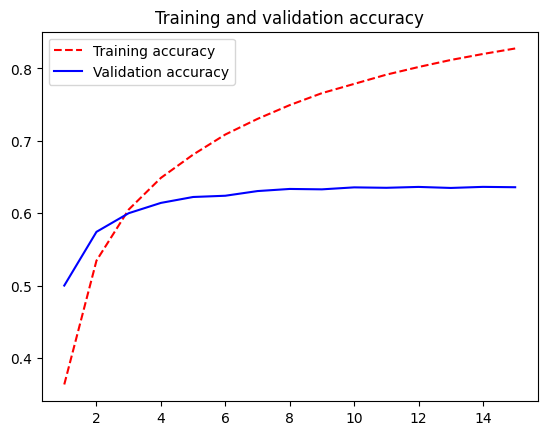

In [35]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [36]:
transformer = keras.models.load_model(
    MODELS_DIR / "transformer-no-positional.en_spa.keras",
    custom_objects={
        "TransformerEncoder": TransformerEncoder,
        "TransformerDecoder": TransformerDecoder,
    }
)
print(f"Val acc: {transformer.evaluate(val_ds)[1]:.3f}")

279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6191 - loss: 0.7164
Val acc: 0.622


#### PositionalEmbedding layer

**Attention in itself ignores word order!**

But we can reinject that information in the form of a **second embedding layer** that is added to the first one, and whose job is to encode positional information. This time we just embed **positions** (1,2,...).

In [37]:
class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    # new in Keras 3, see: https://keras.io/guides/making_new_layers_and_models_via_subclassing/#best-practice-deferring-weight-creation-until-the-shape-of-the-inputs-is-known
    def build(self, input_shape):
        # token embeddings: semantic information
        self.token_embeddings = keras.layers.Embedding(self.input_dim, self.output_dim)
        # position embeddings: syntactic/spatial information
        self.position_embeddings = keras.layers.Embedding(self.sequence_length, self.output_dim)
        super().build(input_shape)

    def call(self, inputs):
        # 1. create token embeddings
        embedded_tokens = self.token_embeddings(inputs)
        # 2. create pos embeddings (as many as our input length)
        positions = keras.ops.cumsum(keras.ops.ones_like(inputs), axis=-1) - 1
        embedded_positions = self.position_embeddings(positions)
        # 3. Both embeddings are simply added together!
        return embedded_tokens + embedded_positions

    # retrieve config as a dict (required for Keras layers)
    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
            "output_dim": self.output_dim,
        })
        return config

After studying the manual version, it's possible to use [`keras_hub.layers.PositionEmbedding`](https://keras.io/keras_hub/api/modeling_layers/position_embedding/) (see also the [other embedding layers here](https://keras.io/keras_hub/api/modeling_layers/)).

#### End-to-end Transformer

In [38]:
EMBED_DIM = 256
INTERMEDIATE_DIM = 2048
NUM_HEAD = 8

encoder_inputs = keras.Input(shape=(None,), dtype="int32", name="english")
x = PositionalEmbedding(SEQUENCE_LENGTH, VOCAB_SIZE, EMBED_DIM)(encoder_inputs)
encoder_outputs = TransformerEncoder(INTERMEDIATE_DIM, NUM_HEAD)(
    inputs=x,
    padding_mask=encoder_inputs != 0,
)

decoder_inputs = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = PositionalEmbedding(SEQUENCE_LENGTH, VOCAB_SIZE, EMBED_DIM)(decoder_inputs)
x = TransformerDecoder(INTERMEDIATE_DIM, NUM_HEAD)(
    decoder_sequence=x,
    encoder_sequence=encoder_outputs,
    encoder_padding_mask=encoder_inputs != 0,
)
x = keras.layers.Dropout(0.5)(x)
decoder_outputs = keras.layers.Dense(VOCAB_SIZE, activation="softmax")(x)
transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [39]:
transformer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ spanish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 256) │  1,315,072 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │  1,578,752 │ positional_embed… │
│ (TransformerDecode… │                   │            │ not_equal_5[0][0… │
│                     │                   │            │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, None, 256) │          0 │ transformer_deco… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, None,      │  3,855,000 │ dropout_11[0][0]  │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,439,064 (55.08 MB)

 Trainable params: 14,439,064 (55.08 MB)

 Non-trainable params: 0 (0.00 B)

#### Training the sequence-to-sequence Transformer

In [40]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"]
)

history = transformer.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "transformer-positional.en_spa.keras",
            save_best_only=True

        )
    ],
)

Epoch 1/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.2769 - loss: 1.7813 - val_accuracy: 0.5144 - val_loss: 1.0076
Epoch 2/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5284 - loss: 1.0025 - val_accuracy: 0.6058 - val_loss: 0.7815
Epoch 3/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6154 - loss: 0.7621 - val_accuracy: 0.6372 - val_loss: 0.7054
Epoch 4/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6631 - loss: 0.6271 - val_accuracy: 0.6574 - val_loss: 0.6575
Epoch 5/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6962 - loss: 0.5386 - val_accuracy: 0.6665 - val_loss: 0.6433
Epoch 6/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7206 - loss: 0.4753 - val_accuracy: 0.6728 - val_loss: 0.6342
Epoch 7/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7412 - loss: 0.4251 - val_accuracy: 0.6758 - val_loss: 0.6340
Epoch 8/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7574 - loss: 

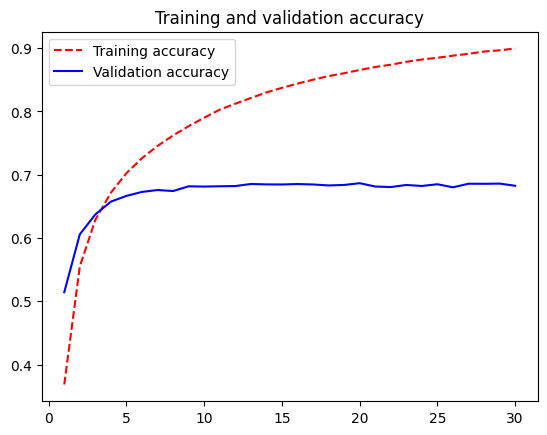

In [41]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [42]:
transformer = keras.models.load_model(
    MODELS_DIR / "transformer-positional.en_spa.keras",
    custom_objects={
        "TransformerEncoder": TransformerEncoder,
        "TransformerDecoder": TransformerDecoder,
        "PositionalEmbedding": PositionalEmbedding,
    }
)
print(f"Val acc: {transformer.evaluate(val_ds)[1]:.3f}")

279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6730 - loss: 0.6393
Val acc: 0.676


#### Translating new sentences with our Transformer model

In [43]:
def decode_sequence(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = spanish_tokenizer(
            [decoded_sentence])[:, :-1]
        predictions = transformer(
            [tokenized_input_sentence, tokenized_target_sentence])
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

In [44]:
spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20
test_eng_texts = [pair[0] for pair in test_pairs]

In [45]:
for _ in range(20):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(decode_sequence(input_sentence))

-
I like watching planes take off.
[start] me gusta ver la dirección [end]
-
I just want to be loved.
[start] solo quiero ser amado [end]
-
I knew all along that he was telling a lie.
[start] sabía todo lo que estaba diciendo era mentira [end]
-
Tom will always remember you.
[start] tom siempre se recordará [end]
-
This is your dog.
[start] este es tu perro [end]
-
All the furniture was covered with dust.
[start] todos los muebles estaban [UNK] con el polvo [end]
-
Let me leave!
[start] déjame irte [end]
-
She always gets up at six.
[start] ella siempre se levanta a las seis [end]
-
Could you stand up, please?
[start] podrías quedarte por favor [end]
-
The bird picked up the twig with its beak and flew to its nest.
[start] el pájaro recogió en [UNK] con [UNK] y el [UNK] es que [UNK] [end]
-
He likes oranges.
[start] a él le gustan las naranjas [end]
-
I wish I had been with you then.
[start] desearía que me quedé contigo entonces [end]
-
We didn't see anything.
[start] nosotros no vimo

---

### Save models to Google Drive

In [46]:
EXPORT=False

if EXPORT:
    # zip models
    !zip seq-to-seq.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp seq-to-seq.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models

## Classification with a pretrained Transformer

Learn about it [in the book](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer/#classification-with-a-pretrained-transformer).

You can also explore training on the same dataset (IDMB, yet again) but building a Transformer Encoder from scratch in [`08.more/2nd-ed.chapter11_part03_transformer.ipynb`](https://github.com/jchwenger/DLWP/tree/main/lectures/08.more/2nd-ed.chapter11_part03_transformer.ipynb).

## Note: Attention is cheap – if your input sequence is short(ish)

The bulk of the computation happens in the `sequence_length` * `sequence_length` matrices!

<!-- <img src="images/transformer/vaswani-huang.attention-is-cheap.png"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/vaswani-huang.attention-is-cheap.png">

<small>[Ashish Vaswani and Anna Huang, "Self-Attention For Generative Models", CS224n Stanford](https://web.stanford.edu/class/cs224n/slides/cs224n-2019-lecture14-transformers.pdf)</small>

## Summary

### Experiments

- Encapsulate the transformer model into a class, so that it's easier to create different models with various hyperparameters (number of layers, heads, inner dim, etc.)
- Try and change the tokenization to use e.g. BPE (you can use off-the-shelf classes found on [`KerasHub`](https://keras.io/keras_hub/api/tokenizers/)).

### Attention

- **Neural attention** is a way to create context-aware word representations, the basis for the **Transformer**.
  - The operations are $\bbox[5px,border:2px solid red]{“softmax(\mathrm{Queries} \cdot \mathrm{Keys)} \cdot \mathrm{Values}”}$.
  - **Multi-head** attention allows us to split the attention process (similar to different filters in a CNN), looking up different types of information in the input.
  - To enforce causality / prevent lookaheads into the future, we use **masking** to zero out values.
  - Attention **ignores order**: reinject that information with **Position Encoding**.
  

### Transformer  

- The full **Transformer** architecture consists of a TransformerEncoder and a TransformerDecoder, has yielded great results in many fields.  
    - The first half, the **TransformerEncoder**, can also be used for text classification or any sort of single-input NLP task.  
    - The second half, the **TransformerDecoder**, can be used to generate text (like an RNN).  
    - Both were developed together with translation in mind, on the basis of the **sequence to sequence** model.